<img src="https://www.truedata.in/content/uploads/blogimages/best-momentum-indicators-for-strategic-trading.webp"/>

In [2]:
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.express as px
import yfinance as yf

In [3]:
# Get Apple's stock data from yahoo finance
stock = yf.Ticker("AAPL")
data = stock.history(period="1y")
print(data.head())

                                 Open        High         Low       Close  \
Date                                                                        
2025-04-21 00:00:00-04:00  192.431301  192.958999  188.986309  192.321777   
2025-04-22 00:00:00-04:00  195.268929  200.715193  195.119586  198.873230   
2025-04-23 00:00:00-04:00  205.106062  207.097383  201.919951  203.712143   
2025-04-24 00:00:00-04:00  204.000865  207.923770  202.059330  207.465759   
2025-04-25 00:00:00-04:00  205.474466  208.839803  205.305205  208.371841   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-04-21 00:00:00-04:00  46742500        0.0           0.0  
2025-04-22 00:00:00-04:00  52976400        0.0           0.0  
2025-04-23 00:00:00-04:00  52929200        0.0           0.0  
2025-04-24 00:00:00-04:00  47311000        0.0           0.0  
2025-04-25 00:00:00-04:00  38222300        0.0           0.0  


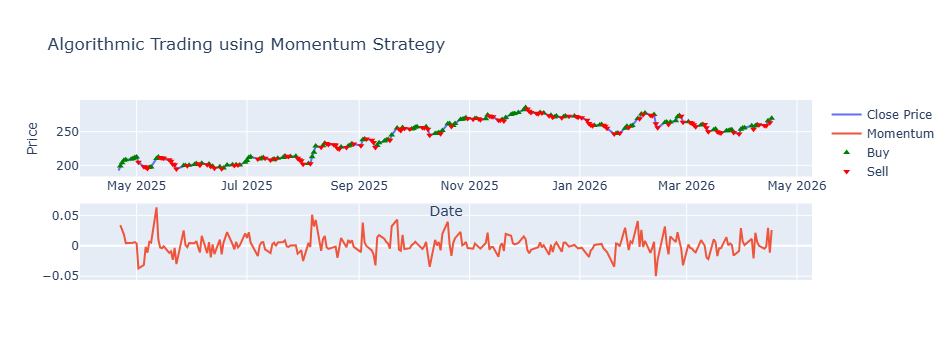

In [4]:
# Calculation of momentum
data['momentum'] = data['Close'].pct_change()

# Creating subplots to show momentum and buying/selling markers
figure = make_subplots(rows=2, cols=1)
figure.add_trace(go.Scatter(x=data.index, 
                         y=data['Close'], 
                         name='Close Price'))
figure.add_trace(go.Scatter(x=data.index, 
                         y=data['momentum'], 
                         name='Momentum', 
                         yaxis='y2'))

# Adding the buy and sell signals
figure.add_trace(go.Scatter(x=data.loc[data['momentum'] > 0].index, 
                         y=data.loc[data['momentum'] > 0]['Close'], 
                         mode='markers', name='Buy', 
                         marker=dict(color='green', symbol='triangle-up')))

figure.add_trace(go.Scatter(x=data.loc[data['momentum'] < 0].index, 
                         y=data.loc[data['momentum'] < 0]['Close'], 
                         mode='markers', name='Sell', 
                         marker=dict(color='red', symbol='triangle-down')))

figure.update_layout(title='Algorithmic Trading using Momentum Strategy',
                  xaxis_title='Date',
                  yaxis_title='Price')
figure.update_yaxes(title="Momentum", secondary_y=True)
figure.show()


In [5]:
# ================================
# FEATURE ENGINEERING (CORRECT WAY)
# ================================

data['return'] = data['Close'].pct_change()

# Lag features (geçmiş bilgi)
for lag in range(1, 6):
    data[f'return_lag_{lag}'] = data['return'].shift(lag)

# Moving averages (shifted → leakage yok)
data['MA20'] = data['Close'].rolling(20).mean().shift(1)
data['MA50'] = data['Close'].rolling(50).mean().shift(1)

# Volatility
data['volatility'] = data['return'].rolling(20).std().shift(1)

# TARGET (yarın artacak mı?)
data['target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

df = data.dropna()

In [7]:
from sklearn.ensemble import GradientBoostingClassifier

features = [col for col in df.columns if 'lag' in col] + ['MA20', 'MA50', 'volatility']

X = df[features]
y = df['target']

split = int(len(df)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("===== CLASSIFICATION METRICS =====")

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision : {precision_score(y_test, y_pred):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.3f}")

===== CLASSIFICATION METRICS =====
Accuracy  : 0.500
Precision : 0.500
Recall    : 0.750
F1 Score  : 0.600


In [9]:
df_test = df.iloc[split:].copy()

df_test['prediction'] = y_pred

# Strategy return
df_test['strategy_return'] = df_test['prediction'] * df_test['return']

# Buy & Hold
df_test['buy_hold'] = df_test['return']

# Cumulative
df_test['strategy_cum'] = (1 + df_test['strategy_return']).cumprod()
df_test['buy_hold_cum'] = (1 + df_test['buy_hold']).cumprod()

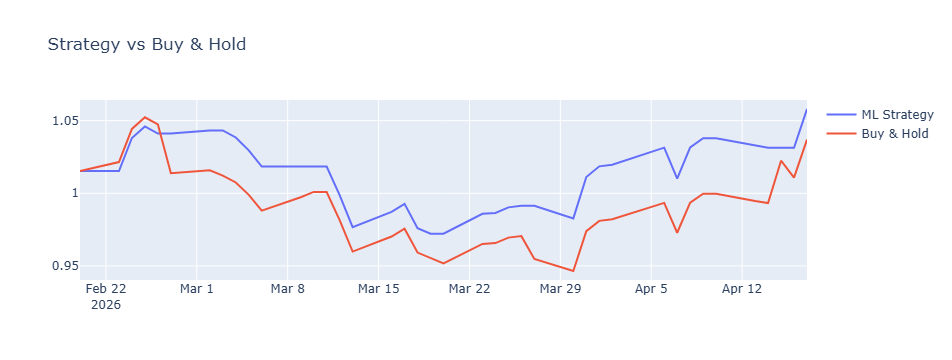

In [10]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_test.index,
    y=df_test['strategy_cum'],
    name="ML Strategy"
))

fig.add_trace(go.Scatter(
    x=df_test.index,
    y=df_test['buy_hold_cum'],
    name="Buy & Hold"
))

fig.update_layout(title="Strategy vs Buy & Hold")
fig.show()

## Summary 

We try to use Classification : The goal is to predict whether the stock price will increase the next day.
In financial markets, accuracy alone is not sufficient.
A model can have:

High accuracy
But still lose mone

We evaluate the model based on trading performance.

If prediction = 1 → take position
If prediction = 0 → stay out